# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
import numpy as np

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.prefab import load_prefab
from AFL.double_agent.GPyTorchExtrapolator import DirichletGPExtrapolator 

from tqdm.auto import tqdm

# Build Virtual Instrument

## Load Boundary Dataset

In [3]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset

<xarray.Dataset> Size: 500kB
Dimensions:      (component: 3, sample: 15625)
Coordinates:
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    composition  (component, sample) float64 375kB -3.507 -3.507 ... 9.008 9.558
    labels       (sample) int64 125kB 0 0 0 0 0 0 0 0 0 0 ... 2 2 2 2 2 2 2 2 2
Attributes:
    labels:          labels
    components:      composition
    components_dim:  component

In [4]:
boundary_dataset.close()

In [5]:
plot_scatter_plotly(
    dataset=boundary_dataset.isel(sample=slice(None,None,None)),
    component_variable='composition',
    labels='labels',
    discrete_labels=True,
)

## Instantiate Instrument and Draw Boundaries

In [6]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)


In [7]:
# Create a 3D scatter plot with plotly
fig = go.Figure()

# Add points for each phase with different colors
colors = ['red', 'blue', 'green']
phase_names = ['Phase 0', 'Phase 1', 'Phase 2']

# Add hull meshes if they exist
for i, hull in enumerate(inst_client.hulls.values()):
    if hasattr(hull, 'vertices') and hasattr(hull, 'faces'):
        vertices = hull.vertices
        faces = hull.faces
        
        fig.add_trace(go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1], 
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=colors[i],
            opacity=0.3,
            name=f'{phase_names[i]} Hull',
            showlegend=True
        ))
# Add cube wireframe from (0,0,0) to (80,40,12)
cube_vertices = [
    [0, 0, 0], [80, 0, 0], [80, 50, 0], [0, 50, 0],  # bottom face
    [0, 0, 12], [80, 0, 12], [80, 50, 12], [0, 50, 12]  # top face
]

# Define the edges of the cube
cube_edges = [
    # Bottom face edges
    [0, 1], [1, 2], [2, 3], [3, 0],
    # Top face edges  
    [4, 5], [5, 6], [6, 7], [7, 4],
    # Vertical edges
    [0, 4], [1, 5], [2, 6], [3, 7]
]

# Add each edge as a line
for edge in cube_edges:
    p1, p2 = cube_vertices[edge[0]], cube_vertices[edge[1]]
    fig.add_trace(go.Scatter3d(
        x=[p1[0], p2[0]],
        y=[p1[1], p2[1]],
        z=[p1[2], p2[2]],
        mode='lines',
        line=dict(color='black', width=4),
        showlegend=False
    ))

fig.update_layout(
    title='3D Phase Diagram with Concave Hulls',
    scene=dict(
        xaxis_title='Protein Concentration',
        yaxis_title='Temperature',
        zaxis_title='Glycerol Concentration',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1000,
    height=800
)

fig.show()


## Add sasmodels

In [8]:

# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

## Test Virtual Instrument

In [9]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds['labels'] = ds.attrs['labels']
    ds_list.append(ds)

ds = xr.concat(ds_list,dim='sample')
ds

<xarray.Dataset> Size: 43kB
Dimensions:      (sample: 6, q: 281, component: 3)
Coordinates:
  * q            (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I            (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    I_noiseless  (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    dI           (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    composition  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
    labels       (sample) <U1 24B '2' '1' '1' '1' '0' '0'
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [10]:
plot_scatter_plotly(dataset=ds, component_variable='composition',labels='labels',discrete_labels=True)

In [11]:
plot_sas_plotly( dataset=ds)

# Virtual Active Learning

## Initial Dataset

In [12]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds_list.append(ds)

ds_init = xr.concat(ds_list,dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:      (sample: 6, q: 281, component: 3)
Coordinates:
  * q            (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I            (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    I_noiseless  (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    dI           (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    composition  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

## Build Pipeline

In [17]:
with Pipeline(name = "find_boundaries") as p:
    CartesianGrid(
        output_variable="composition_grid",
        sample_dim="grid",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 25},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 25},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 25}}
    )

    Standardize(
        input_variable="composition",
        output_variable="normalized_composition",
        dim="sample",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    Standardize(
        input_variable="composition_grid",
        output_variable="normalized_composition_grid",
        dim="grid",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative0",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=0,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative1",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=1,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    Similarity(
        input_variable="derivative0",
        output_variable="similarity0",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    Similarity(
        input_variable="derivative1",
        output_variable="similarity1",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    CombineMetric(
        input_variables=['similarity0','similarity1'],
        output_variable="similarity",
        sample_dim="sample",
        combine_by="sum",
        combine_by_powers=None,
        combine_by_coeffs=None,
        name="CombineMetric",
    )

    SpectralClustering(
        input_variable="similarity",
        output_variable="labels",
        dim="sample",
        params={'n_phases': 3},
        name="SpectralClustering",
        use_silhouette=False,
    )

    DirichletGPExtrapolator(
        feature_input_variable="normalized_composition",
        predictor_input_variable="labels",
        output_prefix="extrap",
        grid_variable="normalized_composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 500, "verbose": True},
        name="DirichletGPExtrapolator",
    )

    MaxValueAF(
        input_variables=['extrap_y_prob'],
        grid_variable="composition_grid",
        grid_dim="grid",
        combine_coeffs=None,
        output_prefix=None,
        output_variable="next_sample",
        decision_rtol=0.05,
        excluded_comps_variables=None,
        excluded_comps_dim=None,
        exclusion_radius=0.001,
        count=1,
        name="MaxValueAF",
    )

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> composition_grid
1  ) <Standardize>                       composition ---> normalized_composition
2  ) <Standardize>                       composition_grid ---> normalized_composition_grid
3  ) <SavgolFilter>                      I ---> derivative0
4  ) <SavgolFilter>                      I ---> derivative1
5  ) <SimilarityMetric>                  derivative0 ---> similarity0
6  ) <SimilarityMetric>                  derivative1 ---> similarity1
7  ) <CombineMetric>                     ['similarity0', 'similarity1'] ---> similarity
8  ) <SpectralClustering>                similarity ---> labels
9  ) <DirichletGPExtrapolator>           ['normalized_composition', 'labels', 'normalized_composition_grid'] ---> ['extrap_y_prob']
10 ) <MaxValueAF>                        ['e

### Test Pipeline

In [18]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/11 [00:00<?, ?it/s]

Iter 1/500 - Loss: 11.410   lengthscale: 0.711   noise: 0.744
Iter 51/500 - Loss: 7.728   lengthscale: 0.770   noise: 3.524
Iter 101/500 - Loss: 7.578   lengthscale: 0.663   noise: 3.914
Iter 151/500 - Loss: 7.537   lengthscale: 0.622   noise: 3.744
Iter 201/500 - Loss: 7.520   lengthscale: 0.609   noise: 3.687
Iter 251/500 - Loss: 7.513   lengthscale: 0.601   noise: 3.695
Iter 301/500 - Loss: 7.510   lengthscale: 0.595   noise: 3.705
Iter 351/500 - Loss: 7.509   lengthscale: 0.589   noise: 3.708
Iter 401/500 - Loss: 7.508   lengthscale: 0.585   noise: 3.708
Iter 451/500 - Loss: 7.507   lengthscale: 0.581   noise: 3.705
Iter 500/500 - Loss: 7.507   lengthscale: 0.577   noise: 3.702


<xarray.Dataset> Size: 1MB
Dimensions:                      (q: 281, component: 3, sample: 6, grid: 15625,
                                  log_q: 250, sample_i: 6, sample_j: 6,
                                  AF_sample: 1)
Coordinates:
  * q                            (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * component                    (component) object 24B 'protein' ... 'glycerol'
  * log_q                        (log_q) float64 2kB -2.416 -2.407 ... -0.1983
Dimensions without coordinates: sample, grid, sample_i, sample_j, AF_sample
Data variables: (12/18)
    I                            (sample, q) float64 13kB 1.95 1.937 ... 1.0 1.0
    I_noiseless                  (sample, q) float64 13kB 1.95 1.937 ... 1.0 1.0
    dI                           (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    composition                  (sample, component) int64 144B 40 0 5 ... 50 5
    composition_grid             (grid, component) float64 375kB 0.0 ... 12.0
    normalized_composition       (sample, component) float64 144B 0.5 ... 0.4167
    ...                           ...
    labels                       (sample) int64 48B 1 2 2 2 0 0
    extrap_mean                  (grid) int64 125kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
    extrap_entropy               (grid) float64 125kB 0.8375 0.8366 ... 0.8378
    extrap_y_prob                (grid) float64 125kB 0.8375 0.8366 ... 0.8378
    decision_surface             (grid) float64 125kB 0.9399 0.9385 ... 0.9404
    next_sample                  (AF_sample, component) float64 24B 46.67 ......
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [ ]:
plot_scatter_plotly(
    dataset=ds_result,
    component_variable='composition',
    labels='labels',
    discrete_labels=True,
)

## Run AL

In [ ]:
ds_running = ds_init.copy() 

n_steps = 50
for step in tqdm(np.arange(n_steps)):
    ds_result = p.calculate(ds_running, disable_progress_bar=True)

    next_sample = ds_result['next_sample'].to_pandas().to_dict(orient='records')[0]
    ds_new = inst_client.simple_expose(next_sample)

    ds_running = xr.concat([ds_running, ds_new], dim='sample')

  0%|          | 0/50 [00:00<?, ?it/s]

Iter 1/500 - Loss: 11.410   lengthscale: 0.711   noise: 0.744
Iter 51/500 - Loss: 7.728   lengthscale: 0.770   noise: 3.524
Iter 101/500 - Loss: 7.578   lengthscale: 0.663   noise: 3.914
Iter 151/500 - Loss: 7.537   lengthscale: 0.622   noise: 3.744
Iter 201/500 - Loss: 7.520   lengthscale: 0.609   noise: 3.687
Iter 251/500 - Loss: 7.513   lengthscale: 0.601   noise: 3.695
Iter 301/500 - Loss: 7.510   lengthscale: 0.595   noise: 3.705
Iter 351/500 - Loss: 7.509   lengthscale: 0.589   noise: 3.708
Iter 401/500 - Loss: 7.508   lengthscale: 0.585   noise: 3.708
Iter 451/500 - Loss: 7.507   lengthscale: 0.581   noise: 3.705
Iter 500/500 - Loss: 7.507   lengthscale: 0.577   noise: 3.702
Iter 1/500 - Loss: 11.144   lengthscale: 0.711   noise: 0.744
Iter 51/500 - Loss: 7.625   lengthscale: 0.662   noise: 3.559
Iter 101/500 - Loss: 7.502   lengthscale: 0.553   noise: 3.884
Iter 151/500 - Loss: 7.463   lengthscale: 0.455   noise: 3.662
Iter 201/500 - Loss: 7.443   lengthscale: 0.415   noise: 3.

In [21]:
plot_scatter_plotly(
    dataset=ds_result,
    component_variable='composition',
    labels='labels',
    discrete_labels=True,
)

In [23]:
plot_scatter_plotly(
    dataset=ds_result,
    component_variable='composition_grid',
    labels='extrap_y_prob',
    discrete_labels=False,
)

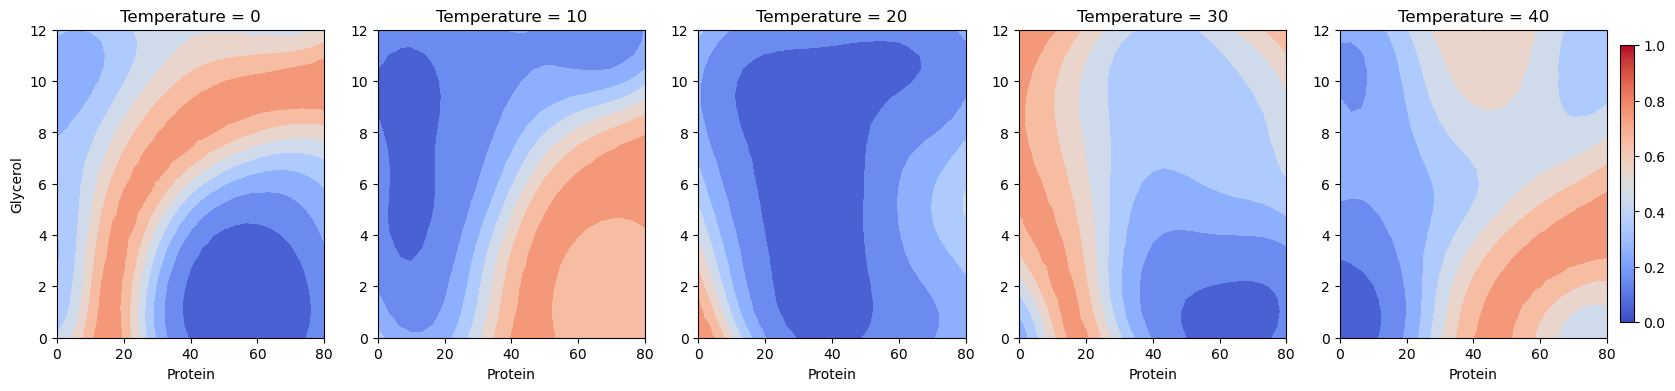

In [55]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

fig, axs = plt.subplots(1,5, figsize=(4*5, 4))
axs = axs.flatten()
composition_grid = ds_result.composition_grid.values
entropy = ds_result['extrap_y_prob'].values
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
cmap = plt.get_cmap('coolwarm') 
mappable = ScalarMappable(norm=norm, cmap=cmap)

for i, value in enumerate(np.arange(0, 50, 10)):
    flags = np.isclose(composition_grid[:,1], value, atol=1.0)
    ax = axs[i]
    ax.tricontourf(composition_grid[flags,0],
                   composition_grid[flags,2],
                   entropy[flags],
                   cmap = cmap,
                   norm = norm
                )
    ax.set_xlabel("Protein")
    ax.set_title("Temperature = %d"%value)
    
axs[0].set_ylabel("Glycerol")
cax = ax.inset_axes([1.05, 0.05, 0.05, 0.9], transform=ax.transAxes)
cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
plt.show()

In [61]:
ds_result

<xarray.Dataset> Size: 2MB
Dimensions:                      (q: 281, component: 3, sample: 55,
                                  grid: 15625, log_q: 250, sample_i: 55,
                                  sample_j: 55, AF_sample: 1)
Coordinates:
  * q                            (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * component                    (component) object 24B 'protein' ... 'glycerol'
  * log_q                        (log_q) float64 2kB -2.416 -2.407 ... -0.1983
Dimensions without coordinates: sample, grid, sample_i, sample_j, AF_sample
Data variables: (12/18)
    I                            (sample, q) float64 124kB 1.95 1.937 ... 1.027
    I_noiseless                  (sample, q) float64 124kB 1.95 1.937 ... 1.027
    dI                           (sample, q) float64 124kB 0.0 0.0 ... 0.0 0.0
    composition                  (sample, component) float64 1kB 40.0 ... 2.5
    composition_grid             (grid, component) float64 375kB 0.0 ... 12.0
    normalized_composition       (sample, component) float64 1kB 0.5 ... 0.2083
    ...                           ...
    labels                       (sample) int64 440B 1 0 0 0 2 2 ... 0 2 1 0 0 0
    extrap_mean                  (grid) int64 125kB 0 0 0 0 0 0 ... 2 2 2 2 2 2
    extrap_entropy               (grid) float64 125kB 0.4125 0.3373 ... 0.1095
    extrap_y_prob                (grid) float64 125kB 0.4125 0.3373 ... 0.1095
    decision_surface             (grid) float64 125kB 0.5074 0.4078 ... 0.106
    next_sample                  (AF_sample, component) float64 24B 16.67 ......
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

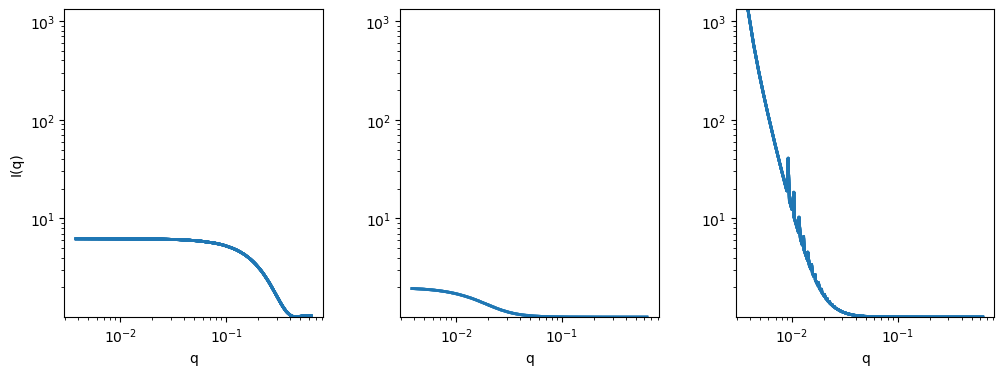

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
fig.subplots_adjust(wspace=0.3)
axs = axs.flatten()
q = ds_result.q.values 
Iq = ds_result.I.values
labels = ds_result.labels.values
for label in np.unique(labels):
    ax = axs[label]
    flags = labels == label
    Iq_current_phase = Iq[flags]
    for i in range(Iq_current_phase.shape[0]):
        ax.loglog(q, 
                  Iq_current_phase[i,:], 
                  color="tab:blue", 
                  lw=2.0, 
                  alpha=0.5
                )
    ax.set_xlabel("q")
    ax.set_ylim([Iq.min(), Iq.max()])
axs[0].set_ylabel("I(q)")
plt.show()

### Plotly interactive code

In [36]:
# ------------------------------------------------------------
# 1. PREPARE STATIC DATA
# ------------------------------------------------------------
comp      = ds_result['composition_grid'].values   # (N, 3)
labels    = ds_result['extrap_y_prob'].values
comp_min  = comp.min(axis=0)
comp_max  = comp.max(axis=0)
comp_rng  = comp_max - comp_min

# initial plane
p0 = np.array([0.5, 0.5, 0.5])   # point in *normalised* coords
n0 = np.array([1.0, 1.0, 0.0])   # normal vector (will be re-normalised)

# ------------------------------------------------------------
# 2. BUILD A SINGLE FIGUREWIDGET
# ------------------------------------------------------------
base = plot_scatter_plotly(
    dataset=ds_result,
    component_variable='composition_grid',
    labels='extrap_y_prob',
    discrete_labels=False,
)

def add_bounding_box(fig, comp_min, comp_max):
    """Add black lines showing the bounding box of the data space."""
    
    # Define the 8 corners of the bounding box
    corners = [
        [comp_min[0], comp_min[1], comp_min[2]],  # 0: min, min, min
        [comp_max[0], comp_min[1], comp_min[2]],  # 1: max, min, min
        [comp_max[0], comp_max[1], comp_min[2]],  # 2: max, max, min
        [comp_min[0], comp_max[1], comp_min[2]],  # 3: min, max, min
        [comp_min[0], comp_min[1], comp_max[2]],  # 4: min, min, max
        [comp_max[0], comp_min[1], comp_max[2]],  # 5: max, min, max
        [comp_max[0], comp_max[1], comp_max[2]],  # 6: max, max, max
        [comp_min[0], comp_max[1], comp_max[2]],  # 7: min, max, max
    ]
    
    # Define the 12 edges of the bounding box
    edges = [
        # Bottom face edges
        [0, 1], [1, 2], [2, 3], [3, 0],
        # Top face edges
        [4, 5], [5, 6], [6, 7], [7, 4],
        # Vertical edges
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]
    
    # Add each edge as a line trace
    for start_idx, end_idx in edges:
        start = corners[start_idx]
        end = corners[end_idx]
        
        fig.add_scatter3d(
            x=[start[0], end[0]],
            y=[start[1], end[1]],
            z=[start[2], end[2]],
            mode='lines',
            line=dict(color='black', width=3),
            showlegend=False,
            hoverinfo='skip'
        )
    return fig

base = add_bounding_box(base, 
                        ds_result.composition_grid.values.min(axis=0),
                        ds_result.composition_grid.values.max(axis=0)
                        )

fig = go.FigureWidget(base)      # 🌟 becomes live & mutable

# remember which trace contains the points we will filter
scatter_idx = 0  # plot_scatter_plotly puts the scatter first
scatter_trace = fig.data[scatter_idx]

# add a surface trace for the plane so we can move it later
plane_trace = go.Surface(
    showscale=False,
    opacity=0.3,
    colorscale='Greys',
    name='Slicing Plane'
)
fig.add_trace(plane_trace)
plane_idx = len(fig.data) - 1

# ------------------------------------------------------------
# 3. WIDGETS
# ------------------------------------------------------------
def float_slider(description, vmin, vmax, val, step=0.02):
    return widgets.FloatSlider(description=description, min=vmin,
                               max=vmax, step=step, value=val,
                               continuous_update=True)

px, py, pz = (float_slider(c, 0, 1, 0.5) for c in ('px','py','pz'))
nx, ny, nz = (float_slider(c, -1, 1, d, 0.05)
              for c, d in zip(('nx','ny','nz'), (1.0, 1.0, 0.0)))

# ------------------------------------------------------------
# 4. UPDATE IN-PLACE
# ------------------------------------------------------------
def update_plane(_=None):
    # current widget values
    p = np.array([px.value, py.value, pz.value])
    n = np.array([nx.value, ny.value, nz.value])
    if np.allclose(n, 0):        # avoid zero-length normal
        n[2] = 1.0
    n /= np.linalg.norm(n)

    # actual point in data coords
    p_actual = comp_min + p * comp_rng

    # mask points on the desired side of the plane
    d = (comp - p_actual) @ n
    mask = d <= 0

    # update scatter directly
    scatter_trace.x = comp[mask, 0]
    scatter_trace.y = comp[mask, 1]
    scatter_trace.z = comp[mask, 2]
    if hasattr(scatter_trace.marker, 'color') and len(scatter_trace.marker.color)==len(comp):
        scatter_trace.marker.color = labels[mask]

    # rebuild plane mesh (small utility)
    size = 0.6 * comp_rng.max()
    u = np.linspace(-size/2, size/2, 10)
    v = np.linspace(-size/2, size/2, 10)
    U, V = np.meshgrid(u, v)

    # two orthogonal vectors in the plane
    v1 = np.cross(n, [1,0,0]) if abs(n[0]) < 0.9 else np.cross(n, [0,1,0])
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(n, v1)

    X = p_actual[0] + U*v1[0] + V*v2[0]
    Y = p_actual[1] + U*v1[1] + V*v2[1]
    Z = p_actual[2] + U*v1[2] + V*v2[2]

    # clip to data bounds
    X = np.clip(X, comp_min[0], comp_max[0])
    Y = np.clip(Y, comp_min[1], comp_max[1])
    Z = np.clip(Z, comp_min[2], comp_max[2])

    # push into plane trace
    plane_trace.x = X
    plane_trace.y = Y
    plane_trace.z = Z

# hook up every slider
for w in (px, py, pz, nx, ny, nz):
    w.observe(update_plane, names='value')

# ------------------------------------------------------------
# 5. DISPLAY
# ------------------------------------------------------------
controls = widgets.VBox([widgets.HBox([px, py, pz]),
                         widgets.HBox([nx, ny, nz])])
display(widgets.HTML('<b>Drag sliders to move / rotate the plane</b>'),
        controls, fig)

update_plane()  # render first time

HTML(value='<b>Drag sliders to move / rotate the plane</b>')

FigureWidget({
    'data': [{'hovertext': [Label: 0.4125282088817265, Label: 0.3372881071311956,
                            Label: 0.29546797484320264, ..., Label:
                            0.13572671081500137, Label: 0.1169551736665394, Label:
                            0.10945042238160185],
              'marker': {'color': {'bdata': ('JsR0t9xm2j+iU13bIJbVP8rhPYLy6N' ... 'Isfl/BP+jr/jXG8L0/2JCpYPEEvD8='),
                                   'dtype': 'f8'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                 